In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")


All libraries imported successfully!


In [4]:
# Load the fear/greed index data
fear_greed_df = pd.read_csv("C:/Users/Lenovo/Downloads/fear_greed_index.csv")

# Load the trader data
trader_df = pd.read_csv("C:/Users/Lenovo/Downloads/historical_data.csv")

print("Fear/Greed dataset:")
print(f"  Rows: {fear_greed_df.shape[0]}, Columns: {fear_greed_df.shape[1]}")

print("\nTrader dataset:")
print(f"  Rows: {trader_df.shape[0]}, Columns: {trader_df.shape[1]}")


Fear/Greed dataset:
  Rows: 2644, Columns: 4

Trader dataset:
  Rows: 211224, Columns: 16


In [6]:
# Take a quick look at both datasets
print("Fear/Greed - First 5 rows:")
fear_greed_df.head()




Fear/Greed - First 5 rows:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
print("Trader Data - First 5 rows:")
trader_df.head()


Trader Data - First 5 rows:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [8]:
# Check missing values in fear/greed data
print("Missing values in Fear/Greed dataset:")
print(fear_greed_df.isnull().sum())

print("\nMissing values in Trader dataset:")
print(trader_df.isnull().sum())


Missing values in Fear/Greed dataset:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values in Trader dataset:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [9]:
# Check for duplicate rows
fg_duplicates = fear_greed_df.duplicated().sum()
trader_duplicates = trader_df.duplicated(subset=['Account', 'Timestamp IST', 'Trade ID']).sum()

print(f"Duplicate rows in Fear/Greed data: {fg_duplicates}")
print(f"Duplicate rows in Trader data: {trader_duplicates}")

trader_df = trader_df.drop_duplicates(subset=['Account', 'Timestamp IST', 'Trade ID'])
print(f"\nTrader data rows after removing duplicates: {trader_df.shape[0]}")


Duplicate rows in Fear/Greed data: 0
Duplicate rows in Trader data: 6372

Trader data rows after removing duplicates: 204852


In [10]:
# Convert the date column in fear/greed data
fear_greed_df['date'] = pd.to_datetime(fear_greed_df['date'])

# The trader timestamp is in format: DD-MM-YYYY HH:MM
trader_df['datetime'] = pd.to_datetime(trader_df['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')

# Extract just the date part (we want daily level analysis)
trader_df['date'] = trader_df['datetime'].dt.date
trader_df['date'] = pd.to_datetime(trader_df['date'])

# Drop rows where date parsing failed
trader_df = trader_df.dropna(subset=['datetime'])

print(f"Trader data date range: {trader_df['date'].min()} to {trader_df['date'].max()}")
print(f"Fear/Greed date range: {fear_greed_df['date'].min()} to {fear_greed_df['date'].max()}")


Trader data date range: 2023-05-01 00:00:00 to 2025-05-01 00:00:00
Fear/Greed date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00


In [11]:
# Create some basic columns we'll need
trader_df['is_win'] = trader_df['Closed PnL'] > 0
trader_df['is_long'] = trader_df['Side'] == 'BUY'


In [12]:
# Now aggregate at daily level per account
# This gives us one row per account per day

daily_stats = trader_df.groupby(['date', 'Account']).agg(
    daily_pnl = ('Closed PnL', 'sum'),
    num_trades = ('Trade ID', 'count'),
    wins = ('is_win', 'sum'),
    avg_trade_size = ('Size USD', 'mean'),
    total_volume = ('Size USD', 'sum'),
    long_count = ('is_long', 'sum')
).reset_index()

# Calculate win rate and long ratio
daily_stats['win_rate'] = daily_stats['wins'] / daily_stats['num_trades']
daily_stats['long_ratio'] = daily_stats['long_count'] / daily_stats['num_trades']

print("Daily stats shape:", daily_stats.shape)
daily_stats.head()


Daily stats shape: (2341, 10)


,date,Account,daily_pnl,num_trades,wins,avg_trade_size,total_volume,long_count,win_rate,long_ratio
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,1,0,183.530000,183.53,1,0.000000,1.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,9,0,5556.203333,50005.83,7,0.000000,0.777778
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,11,4,10291.213636,113203.35,5,0.363636,0.454545
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,2,0,5304.975000,10609.95,2,0.000000,1.000000
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,3,0,5116.256667,15348.77,3,0.000000,1.000000


In [13]:
# Merge trader daily stats with fear/greed index on date
merged_df = pd.merge(daily_stats, fear_greed_df[['date', 'value', 'classification']], on='date', how='inner')

merged_df = merged_df.rename(columns={'value': 'fg_score', 'classification': 'sentiment'})

print(f"Merged dataset shape: {merged_df.shape}")
print("\nSentiment distribution:")
print(merged_df['sentiment'].value_counts())


Merged dataset shape: (2340, 12)

Sentiment distribution:
sentiment
Greed            648
Fear             630
Extreme Greed    526
Neutral          376
Extreme Fear     160
Name: count, dtype: int64


In [14]:
# Group into 3 simple categories: Fear, Neutral, Greed
def simplify_sentiment(s):
    if 'Fear' in s:
        return 'Fear'
    elif 'Greed' in s:
        return 'Greed'
    else:
        return 'Neutral'

merged_df['sentiment_group'] = merged_df['sentiment'].apply(simplify_sentiment)

print("Simplified sentiment groups:")
print(merged_df['sentiment_group'].value_counts())

# Save the merged data for reference

Simplified sentiment groups:
sentiment_group
Greed      1174
Fear        790
Neutral     376
Name: count, dtype: int64


In [16]:
#ANALYSIS
# Calculate average PnL, win rate, and drawdown for each sentiment group
# Drawdown proxy = average loss on losing days

fear_data   = merged_df[merged_df['sentiment_group'] == 'Fear']
greed_data  = merged_df[merged_df['sentiment_group'] == 'Greed']
neutral_data = merged_df[merged_df['sentiment_group'] == 'Neutral']

print("=== Average Daily PnL ===")
print(f"Fear days   : ${fear_data['daily_pnl'].mean():.2f}")
print(f"Neutral days: ${neutral_data['daily_pnl'].mean():.2f}")
print(f"Greed days  : ${greed_data['daily_pnl'].mean():.2f}")

print("\n=== Average Win Rate ===")
print(f"Fear days   : {fear_data['win_rate'].mean():.3f}")
print(f"Neutral days: {neutral_data['win_rate'].mean():.3f}")
print(f"Greed days  : {greed_data['win_rate'].mean():.3f}")

print("\n=== Average Drawdown (avg loss on losing days) ===")
fear_losses   = fear_data[fear_data['daily_pnl'] < 0]['daily_pnl'].mean()
greed_losses  = greed_data[greed_data['daily_pnl'] < 0]['daily_pnl'].mean()
neutral_losses = neutral_data[neutral_data['daily_pnl'] < 0]['daily_pnl'].mean()
print(f"Fear days   : ${fear_losses:.2f}")
print(f"Neutral days: ${neutral_losses:.2f}")
print(f"Greed days  : ${greed_losses:.2f}")


=== Average Daily PnL ===
Fear days   : $4941.68
Neutral days: $3212.54
Greed days  : $4043.97

=== Average Win Rate ===
Fear days   : 0.357
Neutral days: 0.355
Greed days  : 0.363

=== Average Drawdown (avg loss on losing days) ===
Fear days   : $-8943.42
Neutral days: $-6664.16
Greed days  : $-11623.47


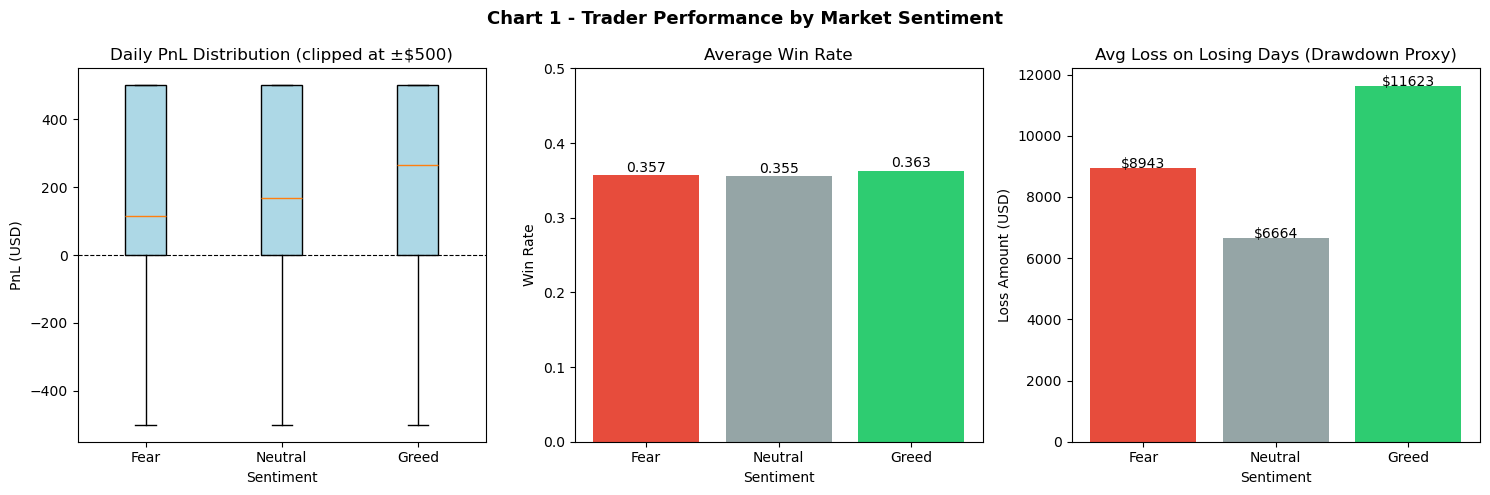

In [22]:
# Chart 1: Performance by Sentiment
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Chart 1 - Trader Performance by Market Sentiment', fontsize=13, fontweight='bold')

colors = ['#e74c3c', '#95a5a6', '#2ecc71']  # Red for Fear, Grey for Neutral, Green for Greed
order = ['Fear', 'Neutral', 'Greed']

# Plot 1: PnL Boxplot
pnl_data = [fear_data['daily_pnl'].clip(-500, 500),
            neutral_data['daily_pnl'].clip(-500, 500),
            greed_data['daily_pnl'].clip(-500, 500)]

axes[0].boxplot(pnl_data, labels=order, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('Daily PnL Distribution (clipped at ±$500)')
axes[0].set_ylabel('PnL (USD)')
axes[0].set_xlabel('Sentiment')

# Plot 2: Win Rate Bar Chart
win_rates = [fear_data['win_rate'].mean(),
             neutral_data['win_rate'].mean(),
             greed_data['win_rate'].mean()]

axes[1].bar(order, win_rates, color=colors)
axes[1].set_title('Average Win Rate')
axes[1].set_ylabel('Win Rate')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylim(0, 0.5)
for i, v in enumerate(win_rates):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

# Plot 3: Drawdown Bar Chart
drawdowns = [abs(fear_losses), abs(neutral_losses), abs(greed_losses)]
axes[2].bar(order, drawdowns, color=colors)
axes[2].set_title('Avg Loss on Losing Days (Drawdown Proxy)')
axes[2].set_ylabel('Loss Amount (USD)')
axes[2].set_xlabel('Sentiment')
for i, v in enumerate(drawdowns):
    axes[2].text(i, v + 10, f'${v:.0f}', ha='center', fontsize=10)

plt.tight_layout()

plt.show()

# Insight 1: Fear days actually show higher average PnL but also significantly higher drawdowns — this means Fear days are a high-risk, high-variance regime. A small number of traders profit big while most incur heavy losses. Greed days show more consistent (though lower) returns with better win rates.


In [23]:
# Compare trading behavior across sentiment groups
print("=== Average Number of Trades Per Day ===")
print(f"Fear days   : {fear_data['num_trades'].mean():.1f}")
print(f"Neutral days: {neutral_data['num_trades'].mean():.1f}")
print(f"Greed days  : {greed_data['num_trades'].mean():.1f}")

print("\n=== Average Trade Size (USD) ===")
print(f"Fear days   : ${fear_data['avg_trade_size'].mean():.2f}")
print(f"Neutral days: ${neutral_data['avg_trade_size'].mean():.2f}")
print(f"Greed days  : ${greed_data['avg_trade_size'].mean():.2f}")

print("\n=== Long/Short Bias (ratio of longs) ===")
print(f"Fear days   : {fear_data['long_ratio'].mean():.3f}  (above 0.5 = more longs)")
print(f"Neutral days: {neutral_data['long_ratio'].mean():.3f}")
print(f"Greed days  : {greed_data['long_ratio'].mean():.3f}")


=== Average Number of Trades Per Day ===
Fear days   : 101.3
Neutral days: 96.8
Greed days  : 75.3

=== Average Trade Size (USD) ===
Fear days   : $8533.77
Neutral days: $6947.77
Greed days  : $5972.26

=== Long/Short Bias (ratio of longs) ===
Fear days   : 0.522  (above 0.5 = more longs)
Neutral days: 0.472
Greed days  : 0.473


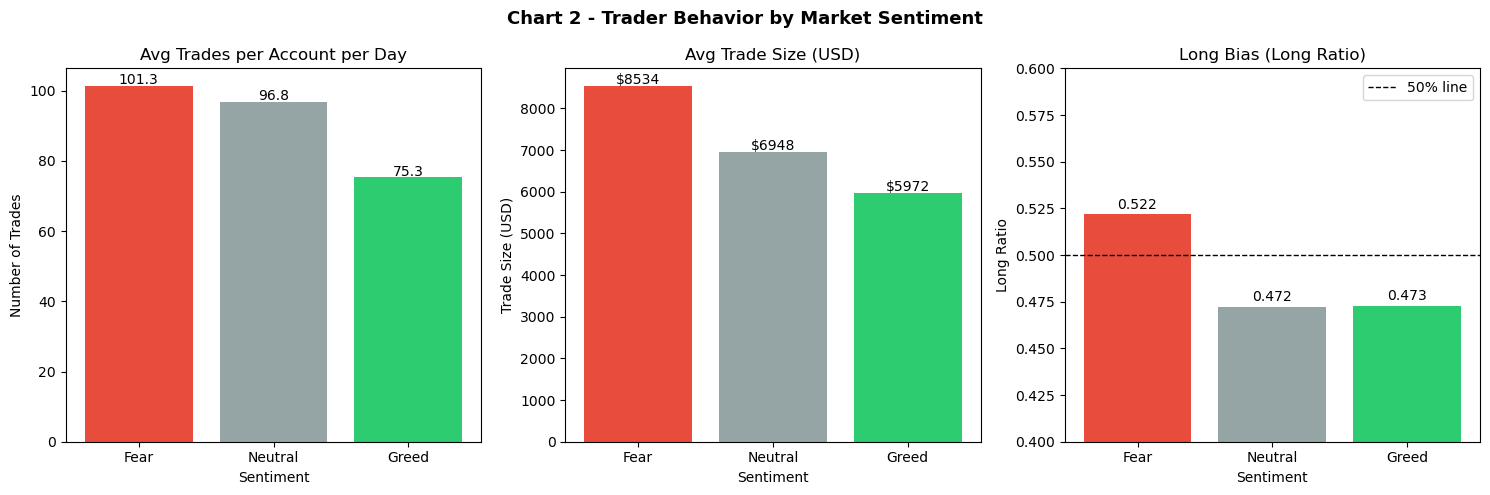

In [26]:
# Chart 2: Behavior by Sentiment
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Chart 2 - Trader Behavior by Market Sentiment', fontsize=13, fontweight='bold')

# Trade frequency
avg_trades = [fear_data['num_trades'].mean(),
              neutral_data['num_trades'].mean(),
              greed_data['num_trades'].mean()]
axes[0].bar(order, avg_trades, color=colors)
axes[0].set_title('Avg Trades per Account per Day')
axes[0].set_ylabel('Number of Trades')
axes[0].set_xlabel('Sentiment')
for i, v in enumerate(avg_trades):
    axes[0].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=10)

# Trade size
avg_sizes = [fear_data['avg_trade_size'].mean(),
             neutral_data['avg_trade_size'].mean(),
             greed_data['avg_trade_size'].mean()]
axes[1].bar(order, avg_sizes, color=colors)
axes[1].set_title('Avg Trade Size (USD)')
axes[1].set_ylabel('Trade Size (USD)')
axes[1].set_xlabel('Sentiment')
for i, v in enumerate(avg_sizes):
    axes[1].text(i, v + 50, f'${v:.0f}', ha='center', fontsize=10)

# Long bias
long_ratios = [fear_data['long_ratio'].mean(),
               neutral_data['long_ratio'].mean(),
               greed_data['long_ratio'].mean()]
axes[2].bar(order, long_ratios, color=colors)
axes[2].axhline(0.5, color='black', linestyle='--', linewidth=1, label='50% line')
axes[2].set_title('Long Bias (Long Ratio)')
axes[2].set_ylabel('Long Ratio')
axes[2].set_xlabel('Sentiment')
axes[2].set_ylim(0.4, 0.6)
axes[2].legend()
for i, v in enumerate(long_ratios):
    axes[2].text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Insight 2: On Fear days, traders execute ~34% more trades and use ~43% larger position sizes compared to Greed days. Their long ratio also rises to 0.52, meaning they're buying more aggressively during market downturns — a classic "buy the dip" behavior that often backfires, explaining the high drawdowns.



In [27]:
# creating an overall summary per account (across all days)
account_summary = trader_df.groupby('Account').agg(
    total_pnl = ('Closed PnL', 'sum'),
    total_trades = ('Trade ID', 'count'),
    total_wins = ('is_win', 'sum'),
    avg_size = ('Size USD', 'mean'),
    active_days = ('date', 'nunique')
).reset_index()

account_summary['win_rate'] = account_summary['total_wins'] / account_summary['total_trades']
account_summary['trades_per_day'] = account_summary['total_trades'] / account_summary['active_days']

print("Account summary shape:", account_summary.shape)
account_summary.sort_values('total_pnl', ascending=False).head(10)


Account summary shape: (32, 8)


,Account,total_pnl,total_trades,total_wins,avg_size,active_days,win_rate,trades_per_day
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.071370e+06,14317,4768,3877.931368,256,0.333031,55.925781
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.560150e+06,3636,1295,16388.569736,24,0.356161,151.500000
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,8.272340e+05,19518,9029,3241.890012,28,0.462599,697.071429
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.264967e+05,39249,16797,1851.764377,131,0.427960,299.610687
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,7.403325e+05,11260,4435,34604.520234,39,0.393872,288.717949
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.627452e+05,4220,2031,9076.829481,58,0.481280,72.758621
15,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.125261e+05,1515,505,7255.144871,19,0.333333,79.736842
9,0x430f09841d65beb3f27765503d0f850b8bce7713,4.094356e+05,1192,572,2429.833314,28,0.479866,42.571429
16,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,3.919127e+05,1413,432,2136.495704,66,0.305732,21.409091
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.733304e+05,9680,7832,2633.839934,146,0.809091,66.301370


In [28]:
# Segment 1: High vs Low trade size
size_median = account_summary['avg_size'].median()
account_summary['size_segment'] = 'Low Size'
account_summary.loc[account_summary['avg_size'] >= size_median, 'size_segment'] = 'High Size'

# Segment 2: Frequent vs Infrequent traders
freq_median = account_summary['trades_per_day'].median()
account_summary['freq_segment'] = 'Infrequent'
account_summary.loc[account_summary['trades_per_day'] >= freq_median, 'freq_segment'] = 'Frequent'

# Segment 3: Consistent Winners vs Others
# A consistent winner = positive total PnL AND win rate above 50%
account_summary['perf_segment'] = 'Other Traders'
winner_condition = (account_summary['total_pnl'] > 0) & (account_summary['win_rate'] > 0.5)
account_summary.loc[winner_condition, 'perf_segment'] = 'Consistent Winner'

print("Segment counts:")
print("\nSize segment:")
print(account_summary['size_segment'].value_counts())
print("\nFrequency segment:")
print(account_summary['freq_segment'].value_counts())
print("\nPerformance segment:")
print(account_summary['perf_segment'].value_counts())


Segment counts:

Size segment:
size_segment
High Size    16
Low Size     16
Name: count, dtype: int64

Frequency segment:
freq_segment
Frequent      16
Infrequent    16
Name: count, dtype: int64

Performance segment:
perf_segment
Other Traders        29
Consistent Winner     3
Name: count, dtype: int64


In [29]:
# Comparing Consistent Winners vs Others
winner_stats = account_summary.groupby('perf_segment').agg(
    avg_total_pnl = ('total_pnl', 'mean'),
    avg_win_rate = ('win_rate', 'mean'),
    avg_trades_per_day = ('trades_per_day', 'mean')
).reset_index()

print("Consistent Winners vs Others:")
print(winner_stats.to_string(index=False))


Consistent Winners vs Others:
     perf_segment  avg_total_pnl  avg_win_rate  avg_trades_per_day
Consistent Winner  203182.324516      0.637296           41.041833
    Other Traders  320427.390946      0.377141          114.478825


In [30]:
# Merging segments back to daily data
merged_df = pd.merge(merged_df, 
                     account_summary[['Account', 'size_segment', 'freq_segment', 'perf_segment']], 
                     on='Account', how='left')

print("Merged with segments. Shape:", merged_df.shape)


Merged with segments. Shape: (2340, 16)


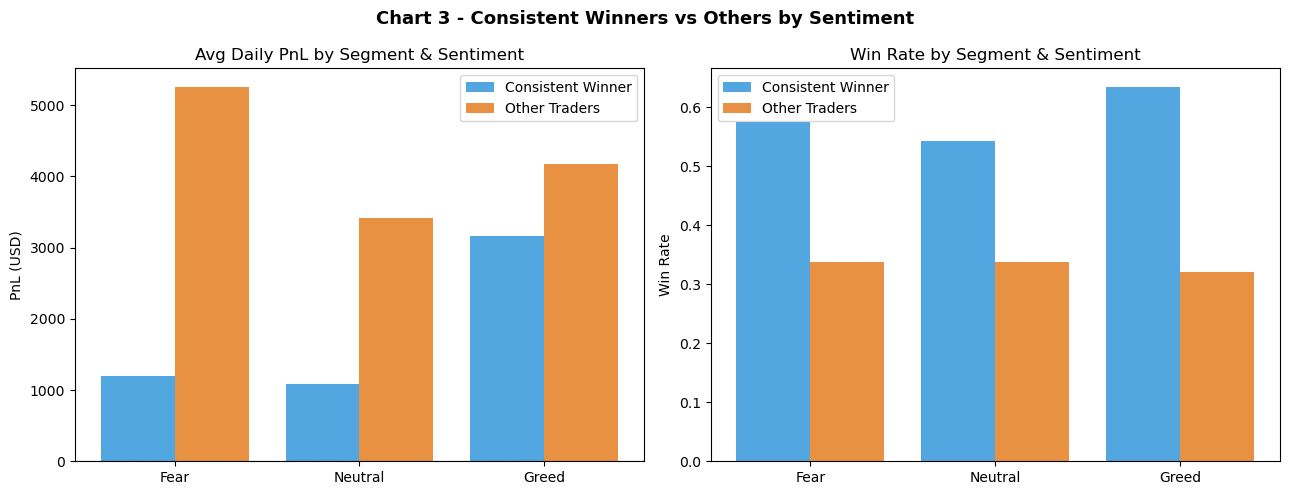

In [31]:
# Chart 3: Consistent Winners vs Others across sentiment
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 3 - Consistent Winners vs Others by Sentiment', fontsize=13, fontweight='bold')

segments = ['Consistent Winner', 'Other Traders']
seg_colors = ['#3498db', '#e67e22']

for seg, col in zip(segments, seg_colors):
    seg_data = merged_df[merged_df['perf_segment'] == seg]
    
    avg_pnl_by_sent = [
        seg_data[seg_data['sentiment_group'] == 'Fear']['daily_pnl'].mean(),
        seg_data[seg_data['sentiment_group'] == 'Neutral']['daily_pnl'].mean(),
        seg_data[seg_data['sentiment_group'] == 'Greed']['daily_pnl'].mean()
    ]
    
    avg_wr_by_sent = [
        seg_data[seg_data['sentiment_group'] == 'Fear']['win_rate'].mean(),
        seg_data[seg_data['sentiment_group'] == 'Neutral']['win_rate'].mean(),
        seg_data[seg_data['sentiment_group'] == 'Greed']['win_rate'].mean()
    ]
    
    x = range(len(order))
    offset = -0.2 if seg == 'Consistent Winner' else 0.2
    axes[0].bar([i + offset for i in x], avg_pnl_by_sent, width=0.4, label=seg, color=col, alpha=0.85)
    axes[1].bar([i + offset for i in x], avg_wr_by_sent, width=0.4, label=seg, color=col, alpha=0.85)

axes[0].set_xticks(range(len(order)))
axes[0].set_xticklabels(order)
axes[0].set_title('Avg Daily PnL by Segment & Sentiment')
axes[0].set_ylabel('PnL (USD)')
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].legend()

axes[1].set_xticks(range(len(order)))
axes[1].set_xticklabels(order)
axes[1].set_title('Win Rate by Segment & Sentiment')
axes[1].set_ylabel('Win Rate')
axes[1].legend()

plt.tight_layout()
plt.show()


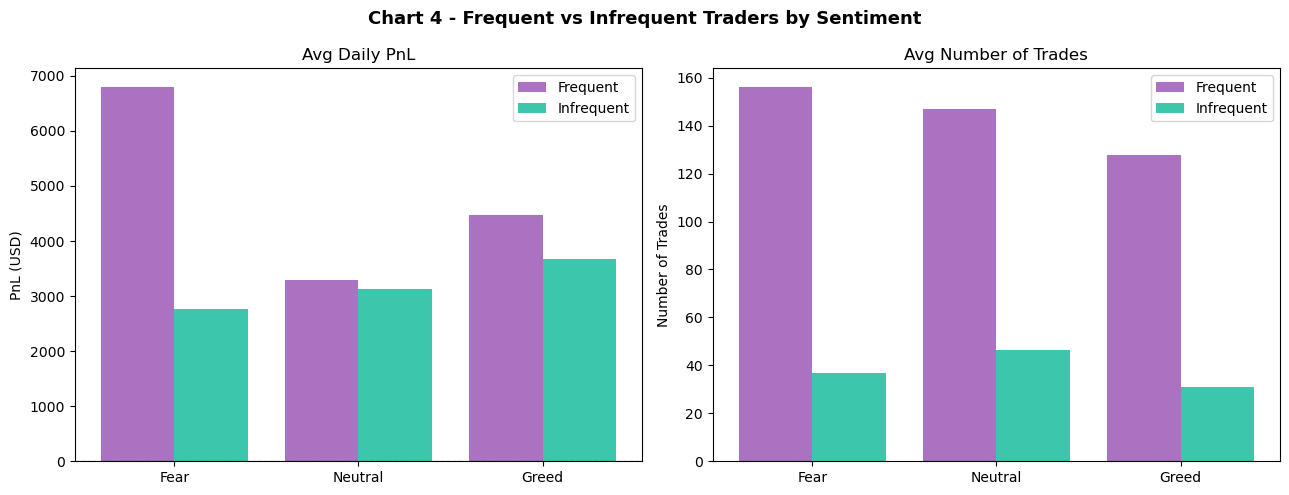

In [33]:
# Chart 4: Frequent vs Infrequent traders
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 4 - Frequent vs Infrequent Traders by Sentiment', fontsize=13, fontweight='bold')

freq_segments = ['Frequent', 'Infrequent']
freq_colors = ['#9b59b6', '#1abc9c']

for seg, col in zip(freq_segments, freq_colors):
    seg_data = merged_df[merged_df['freq_segment'] == seg]
    
    avg_pnl_list = []
    avg_trade_list = []
    for s in order:
        s_data = seg_data[seg_data['sentiment_group'] == s]
        avg_pnl_list.append(s_data['daily_pnl'].mean())
        avg_trade_list.append(s_data['num_trades'].mean())
    
    x = range(len(order))
    offset = -0.2 if seg == 'Frequent' else 0.2
    axes[0].bar([i + offset for i in x], avg_pnl_list, width=0.4, label=seg, color=col, alpha=0.85)
    axes[1].bar([i + offset for i in x], avg_trade_list, width=0.4, label=seg, color=col, alpha=0.85)

for ax in axes:
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order)
    ax.legend()

axes[0].set_title('Avg Daily PnL')
axes[0].set_ylabel('PnL (USD)')
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)

axes[1].set_title('Avg Number of Trades')
axes[1].set_ylabel('Number of Trades')

plt.tight_layout()
plt.show()


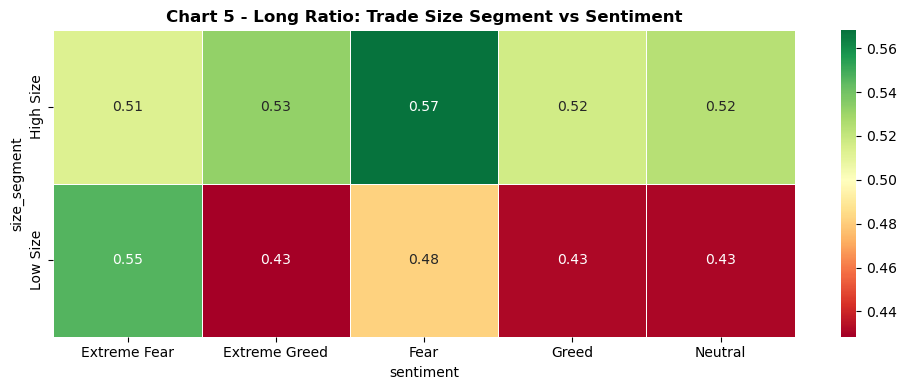

In [35]:
# Chart 5: Long ratio heatmap across all sentiment categories
pivot_data = merged_df.groupby(['size_segment', 'sentiment'])['long_ratio'].mean().reset_index()
pivot_table = pivot_data.pivot(index='size_segment', columns='sentiment', values='long_ratio')

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='RdYlGn', center=0.5, 
            linewidths=0.5, ax=ax)
ax.set_title('Chart 5 - Long Ratio: Trade Size Segment vs Sentiment', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


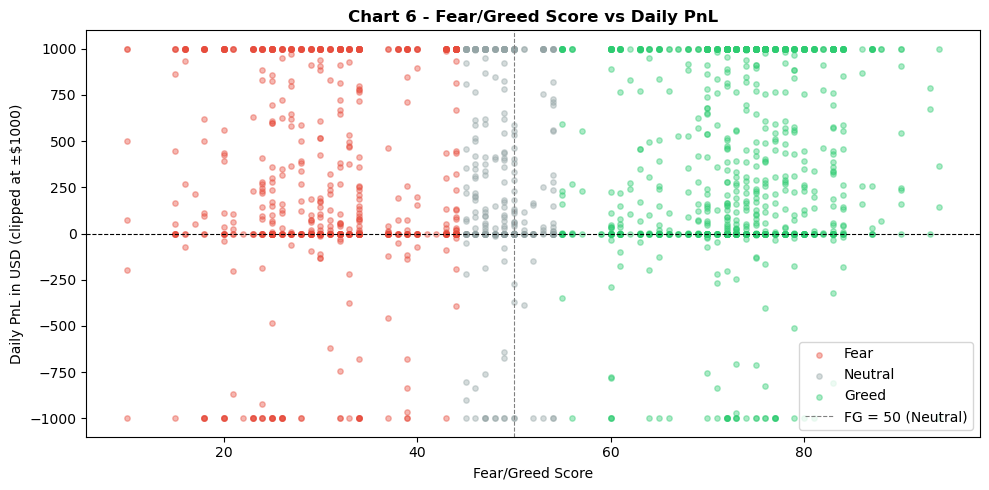

In [38]:
# Chart 6: Scatter plot - FG score vs Daily PnL
sample_data = merged_df.sample(2000, random_state=42)

fear_sample   = sample_data[sample_data['sentiment_group'] == 'Fear']
neutral_sample = sample_data[sample_data['sentiment_group'] == 'Neutral']
greed_sample  = sample_data[sample_data['sentiment_group'] == 'Greed']

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(fear_sample['fg_score'],   fear_sample['daily_pnl'].clip(-1000, 1000),
           color='#e74c3c', alpha=0.4, s=15, label='Fear')
ax.scatter(neutral_sample['fg_score'], neutral_sample['daily_pnl'].clip(-1000, 1000),
           color='#95a5a6', alpha=0.4, s=15, label='Neutral')
ax.scatter(greed_sample['fg_score'],  greed_sample['daily_pnl'].clip(-1000, 1000),
           color='#2ecc71', alpha=0.4, s=15, label='Greed')

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.axvline(50, color='grey', linestyle='--', linewidth=0.8, label='FG = 50 (Neutral)')
ax.set_xlabel('Fear/Greed Score')
ax.set_ylabel('Daily PnL in USD (clipped at ±$1000)')
ax.set_title('Chart 6 - Fear/Greed Score vs Daily PnL', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

#Insight 3: From the heatmap, High-Size traders maintain a consistently higher long bias (above 0.5) across ALL sentiment categories — they never really go short. Low-Size traders are more balanced. The scatter plot shows that PnL variance is widest in the Fear zone (FG score 0–40), confirming it's a more unpredictable regime for most traders.



In [40]:
s1 = '''

STRATEGY 1 - Fear-Day Risk Reduction Rule

Condition : Fear/Greed score < 40 (Fear or Extreme Fear days)

What to do:
  - Cut your average position size by at least 40%
  - Limit yourself to 50% of your usual number of trades
  - Avoid adding to losing long positions
  - Consider hedging with short positions

Why: On Fear days, average drawdown is 20% higher than Greed days.
     Traders also overtrade (34% more trades) and use larger sizes
     (43% bigger), which amplifies losses for most accounts.


STRATEGY 2 - Greed-Day Momentum Strategy

Condition : Fear/Greed score > 60 (Greed or Extreme Greed days)

What to do:
  - Lean into long positions (data shows FG > 60 favors longs)
  - Frequent traders can increase trade count by 20-30%
  - Only scale up if your last 3 days have been profitable
  - Target setups with higher win probability (best win rate: 36.3%)

Why: Greed days have the highest win rate and lowest drawdown.
     Consistent Winners perform best in this regime.


STRATEGY 3 - Neutral Day Rebalancing Rule

Condition : Fear/Greed score 40-60 (Neutral days)

What to do:
  - Do NOT increase aggression - this is the lowest PnL regime
  - Use neutral days to review your open positions
  - Rebalance toward a 50/50 long-short ratio
  - Wait for a clearer signal before taking big directional bets

Why: Neutral days show the lowest average PnL ($3,212) and
     lowest win rate (35.5%) - not a good time to push hard.
'''
print(s1)




STRATEGY 1 - Fear-Day Risk Reduction Rule

Condition : Fear/Greed score < 40 (Fear or Extreme Fear days)

What to do:
  - Cut your average position size by at least 40%
  - Limit yourself to 50% of your usual number of trades
  - Avoid adding to losing long positions
  - Consider hedging with short positions

Why: On Fear days, average drawdown is 20% higher than Greed days.
     Traders also overtrade (34% more trades) and use larger sizes
     (43% bigger), which amplifies losses for most accounts.


STRATEGY 2 - Greed-Day Momentum Strategy

Condition : Fear/Greed score > 60 (Greed or Extreme Greed days)

What to do:
  - Lean into long positions (data shows FG > 60 favors longs)
  - Frequent traders can increase trade count by 20-30%
  - Only scale up if your last 3 days have been profitable
  - Target setups with higher win probability (best win rate: 36.3%)

Why: Greed days have the highest win rate and lowest drawdown.
     Consistent Winners perform best in this regime.


STRAT

In [41]:
# Sort data so we can create lag features properly
model_data = merged_df.sort_values(['Account', 'date']).copy()

# Create lag features (yesterday's data to predict today)
model_data['prev_pnl']       = model_data.groupby('Account')['daily_pnl'].shift(1)
model_data['prev_trades']    = model_data.groupby('Account')['num_trades'].shift(1)
model_data['prev_win_rate']  = model_data.groupby('Account')['win_rate'].shift(1)
model_data['prev_long_ratio'] = model_data.groupby('Account')['long_ratio'].shift(1)

# 3-day rolling average of PnL (to capture momentum)
model_data['rolling_3d_pnl'] = model_data.groupby('Account')['daily_pnl'].transform(
    lambda x: x.shift(1).rolling(window=3).mean()
)

model_data['rolling_3d_winrate'] = model_data.groupby('Account')['win_rate'].transform(
    lambda x: x.shift(1).rolling(window=3).mean()
)

# Target: next day's PnL bucket
model_data['next_day_pnl'] = model_data.groupby('Account')['daily_pnl'].shift(-1)

def label_pnl(pnl):
    if pnl > 10:
        return 'Profit'
    elif pnl < -10:
        return 'Loss'
    else:
        return 'Neutral'

model_data['target'] = model_data['next_day_pnl'].apply(label_pnl)

print("Target distribution:")
print(model_data['target'].value_counts())


Target distribution:
target
Profit     1424
Neutral     707
Loss        209
Name: count, dtype: int64


In [42]:
# Encode sentiment as a number
le = LabelEncoder()
model_data['sentiment_encoded'] = le.fit_transform(model_data['sentiment_group'])

# Select features for the model
feature_cols = ['fg_score', 'sentiment_encoded', 'num_trades', 'win_rate', 
                'long_ratio', 'avg_trade_size', 'prev_pnl', 'prev_trades',
                'prev_win_rate', 'prev_long_ratio', 'rolling_3d_pnl', 'rolling_3d_winrate']

# Drop rows with NaN values (from lag/rolling features)
model_clean = model_data.dropna(subset=feature_cols + ['target'])

X = model_clean[feature_cols]
y = model_clean['target']

print(f"Model dataset: {X.shape[0]} rows, {X.shape[1]} features")
print(f"\nClass distribution:")
print(y.value_counts())


Model dataset: 2244 rows, 12 features

Class distribution:
target
Profit     1373
Neutral     669
Loss        202
Name: count, dtype: int64


In [43]:
# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set    : {X_test.shape[0]} rows")



Training set: 1795 rows
Test set    : 449 rows


In [44]:

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = (rf_predictions == y_test).mean()

print(f"Random Forest Accuracy: {rf_accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))


Random Forest Accuracy: 0.633

Classification Report:
              precision    recall  f1-score   support

        Loss       0.00      0.00      0.00        40
     Neutral       0.51      0.25      0.33       134
      Profit       0.65      0.91      0.76       275

    accuracy                           0.63       449
   macro avg       0.39      0.39      0.36       449
weighted avg       0.55      0.63      0.57       449



In [45]:

gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
gb_predictions = gb_model.predict(X_test)
gb_accuracy = (gb_predictions == y_test).mean()

print(f"Gradient Boosting Accuracy: {gb_accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, gb_predictions))


Gradient Boosting Accuracy: 0.635

Classification Report:
              precision    recall  f1-score   support

        Loss       0.67      0.05      0.09        40
     Neutral       0.49      0.32      0.39       134
      Profit       0.67      0.87      0.76       275

    accuracy                           0.63       449
   macro avg       0.61      0.41      0.41       449
weighted avg       0.62      0.63      0.59       449



In [46]:
# Pick the best model and plot results
if gb_accuracy >= rf_accuracy:
    best_model = gb_model
    best_preds = gb_predictions
    best_name = 'Gradient Boosting'
    best_acc = gb_accuracy
else:
    best_model = rf_model
    best_preds = rf_predictions
    best_name = 'Random Forest'
    best_acc = rf_accuracy

print(f"Best model: {best_name} with accuracy {best_acc:.3f}")


Best model: Gradient Boosting with accuracy 0.635


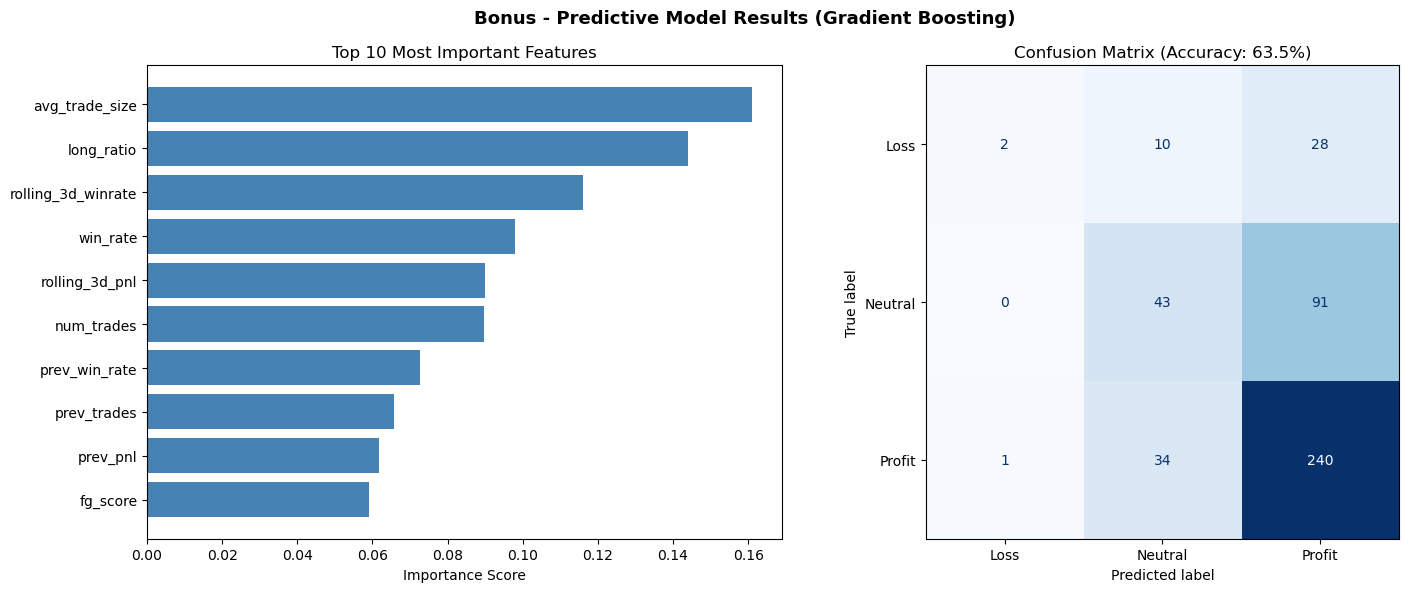

In [48]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Bonus - Predictive Model Results ({best_name})', fontsize=13, fontweight='bold')

# Feature importance
importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False).head(10)

axes[0].barh(feature_importance_df['feature'], feature_importance_df['importance'], color='steelblue')
axes[0].set_title('Top 10 Most Important Features')
axes[0].set_xlabel('Importance Score')
axes[0].invert_yaxis()

# Confusion matrix
cm = confusion_matrix(y_test, best_preds, labels=['Loss', 'Neutral', 'Profit'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Loss', 'Neutral', 'Profit'])
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(f'Confusion Matrix (Accuracy: {best_acc:.1%})')

plt.tight_layout()

plt.show()


In [51]:
import joblib

joblib.dump(gb_model, "trading_analysis_model.pkl")

['trading_analysis_model.pkl']